# XGBoost — Full Deep Dive

In [ ]:
The Story First 📖

Remember Random Forest?
→ 100 trees working TOGETHER
→ each tree independent
→ majority vote at end

XGBoost is different!
→ trees work SEQUENTIALLY
→ each tree LEARNS FROM
  previous tree's mistakes!

Like a student:
Random Forest = 100 students
               giving independent answers

XGBoost = 1 student
          attempting exam 100 times
          learning from each mistake! 🔥

# Boosting vs Bagging:

In [ ]:
BAGGING (Random Forest):
Tree 1 → prediction (independent)
Tree 2 → prediction (independent)
Tree 3 → prediction (independent)
Final  → majority vote

BOOSTING (XGBoost):
Tree 1 → prediction → finds mistakes
Tree 2 → focuses on Tree 1's mistakes
Tree 3 → focuses on Tree 2's mistakes
...
Final  → all trees combined! 🔥

Boosting is smarter!
Each tree improves on previous! ✅

# How XGBoost Works Internally:

In [ ]:
Step 1 → Tree 1 makes predictions
         Error = Actual - Predicted

Step 2 → Tree 2 tries to predict
         Tree 1's ERRORS

Step 3 → Tree 3 tries to predict
         Tree 2's remaining ERRORS

Step 4 → Final = Tree1 + Tree2 + Tree3...
         (weighted sum of all trees)

Example:
Actual marks = 90

Tree 1 predicts → 70  (error = 20)
Tree 2 predicts → 15  (error = 5)
Tree 3 predicts → 4   (error = 1)

Final = 70 + 15 + 4 = 89 ≈ 90 ✅
Getting closer each time!

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report)
from xgboost import XGBClassifier, plot_importance

In [3]:
# BIG dataset — Loan Default Prediction
np.random.seed(42)
n = 500   # 500 customers!

data = {
    "age"              : np.random.randint(21, 65, n),
    "income"           : np.random.randint(20000, 200000, n),
    "loan_amount"      : np.random.randint(5000, 100000, n),
    "loan_tenure"      : np.random.randint(1, 30, n),
    "credit_score"     : np.random.randint(300, 850, n),
    "existing_loans"   : np.random.randint(0, 5, n),
    "employment_years" : np.random.randint(0, 20, n),
    "savings_amount"   : np.random.randint(0, 500000, n),
    "monthly_expenses" : np.random.randint(5000, 50000, n),
    "missed_payments"  : np.random.randint(0, 10, n),
    "education_level"  : np.random.randint(0, 4, n),
    "has_property"     : np.random.randint(0, 2, n),
}

# target → loan default or not
default = (
    (data["credit_score"] < 500)      |
    (data["missed_payments"] > 5)     |
    (data["existing_loans"] > 3)      &
    (data["income"] < 50000)          |
    (data["loan_amount"] > 80000)     &
    (data["savings_amount"] < 10000)
).astype(int)

In [6]:
data["default"]= default
df=pd.DataFrame(data)
print("Dataset Shape:", df.shape)
print("\nDefault Distribution:")
print(df["default"].value_counts())

Dataset Shape: (500, 13)

Default Distribution:
default
1    320
0    180
Name: count, dtype: int64


In [11]:
df

,age,income,loan_amount,loan_tenure,credit_score,existing_loans,employment_years,savings_amount,monthly_expenses,missed_payments,education_level,has_property,default
0,59,40358,10415,7,506,1,14,259994,47351,9,3,0,1
1,49,23267,41159,20,652,3,19,399009,32794,9,3,0,1
2,35,102745,48925,5,631,0,13,496043,33783,2,1,1,0
3,63,109588,10951,1,458,0,5,136643,21998,3,0,1,1
4,28,58513,92388,17,323,0,3,490083,18869,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,46,159639,88691,19,839,2,10,387699,35954,8,2,0,1
496,30,121834,63606,3,790,3,0,494700,36135,3,2,0,0
497,46,104555,15616,29,741,0,10,282844,12081,9,2,1,1
498,54,93698,55072,29,560,3,18,257927,46458,4,1,0,0


# Model Building:

In [16]:
from numpy.testing import verbose

X= df.drop("default",axis=1)
y=df["default"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# XGBoost doesn't need scaling
# but it doesn't hurt!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# XGboost  model 
model=XGBClassifier(
        n_estimators=100,    # number of trees
        max_depth=4,        # depth of each tree
        learning_rate=0.1,  ## how fast model learns
        subsample=0.8,      # % of data per tree
        colsample_bytree=0.8,   # % of features per tree
        gamma=0,                # min loss to split
        reg_alpha=0,   # L1 regularization
         reg_lambda=0,         # L2 regularization
        use_label_encoder=False,     
        eval_metric="logloss",
        random_state=42
)


model.fit(X_train_scaled,y_train,
        eval_set=[(X_test_scaled,y_test)],verbose=False)

c:\Users\admin\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:53:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

# overfitting check
train_acc = accuracy_score(y_train,
            model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test, y_pred)

print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy :", round(test_acc, 4))
print("Difference    :", round(train_acc-test_acc, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy : 0.98
Difference    : 0.02

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        40
           1       0.98      0.98      0.98        60

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



# Parameters Explained

In [ ]:
            n_estimators=100:
            
    number of trees (boosting rounds)

    more trees = better BUT slower
    100  → good starting point ✅
    500  → better accuracy, slower
    1000 → might overfit!

    Unlike Random Forest:
    more trees in XGBoost
    can overfit eventually!

In [ ]:
    learning_rate=0.1:

        how much each tree contributes

        high rate (0.3) → learns fast
                        → might overshoot ❌

        low rate  (0.01) → learns slowly
                        → needs more trees
                        → better accuracy! ✅

        Rule of thumb:
        lower learning_rate +
        higher n_estimators = better! ✅

        Common values: 0.01, 0.05, 0.1

In [ ]:
    max_depth=4:
        depth of each tree

        deeper = more complex = overfit risk!
        3-6 is good range ✅

In [ ]:
    subsample=0.8:
        % of training data used per tree

        0.8 → each tree sees 80% of data
            (like Random Forest bagging!)
            prevents overfitting! ✅

        1.0 → each tree sees all data
            (might overfit)

In [ ]:
    colsample_bytree=0.8:
        % of features used per tree

        0.8 → each tree sees 80% of features
            (like Random Forest feature randomness!)
            prevents overfitting! ✅

In [ ]:
        gamma=0:
        minimum loss reduction to make a split

        gamma=0   → any split is allowed (default)
        gamma=1   → only split if loss reduces by 1
        gamma=5   → very strict, fewer splits

        higher gamma → simpler tree → less overfit

    reg_alpha & reg_lambda:
        regularization parameters

        reg_alpha=0  → L1 regularization (Lasso)
        reg_lambda=1 → L2 regularization (Ridge)

        higher values → more regularization
                    → simpler model
                    → less overfit ✅

# XGBoost vs Random Forest:

In [ ]:
XGBoost        Random Forest
──────────────────────────────────────────
Method        Boosting       Bagging
Trees         Sequential     Independent
Speed         Slower         Faster
Accuracy      Higher ✅       Good
Overfitting   Can overfit    Less prone
Parameters    More complex   Simpler
Interviews    Very asked! 🔥  Very asked! 🔥

# Visualization — 4 Plots:

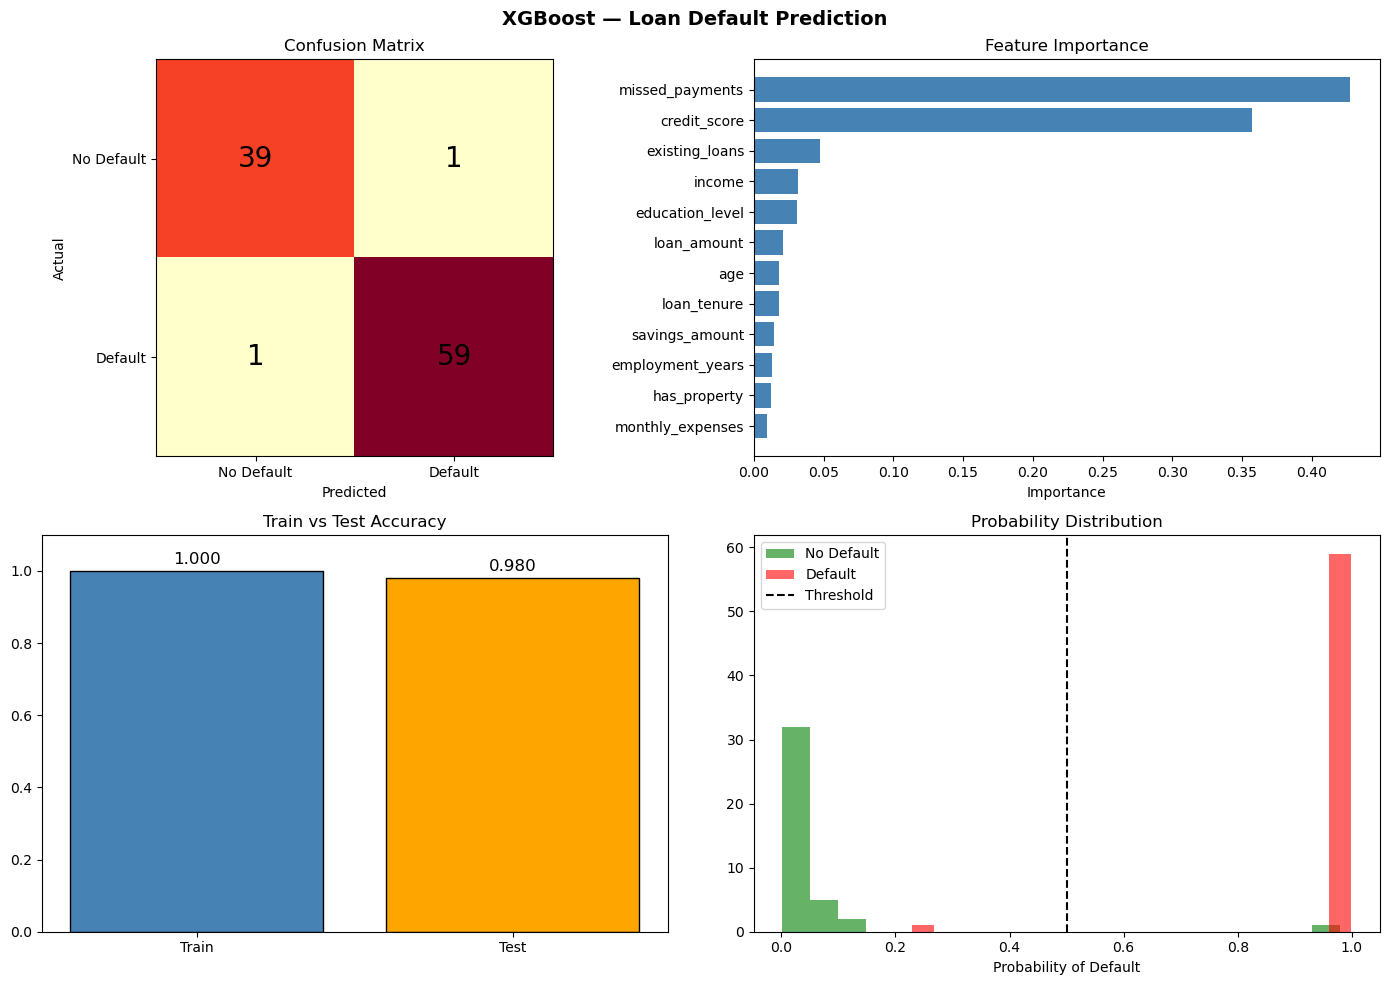

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
axes[0,0].imshow(cm, cmap="YlOrRd")
axes[0,0].set_title("Confusion Matrix")
axes[0,0].set_xlabel("Predicted")
axes[0,0].set_ylabel("Actual")
axes[0,0].set_xticks([0,1])
axes[0,0].set_yticks([0,1])
axes[0,0].set_xticklabels(["No Default","Default"])
axes[0,0].set_yticklabels(["No Default","Default"])
for i in range(2):
    for j in range(2):
        axes[0,0].text(j, i, cm[i,j],
                      ha="center", va="center",
                      color="black", fontsize=20)

# Plot 2 — Feature Importance
feat_imp = pd.DataFrame({
    "feature"   : X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)

axes[0,1].barh(feat_imp["feature"],
               feat_imp["importance"],
               color="steelblue")
axes[0,1].set_title("Feature Importance")
axes[0,1].set_xlabel("Importance")

# Plot 3 — Train vs Test
axes[1,0].bar(["Train","Test"],
              [train_acc, test_acc],
              color=["steelblue","orange"],
              edgecolor="black")
axes[1,0].set_title("Train vs Test Accuracy")
axes[1,0].set_ylim([0, 1.1])
for i, v in enumerate([train_acc, test_acc]):
    axes[1,0].text(i, v+0.02, f"{v:.3f}",
                   ha="center", fontsize=12)

# Plot 4 — Probability Distribution
axes[1,1].hist(y_prob[:,1][y_test==0],
               bins=20, alpha=0.6,
               color="green",
               label="No Default")
axes[1,1].hist(y_prob[:,1][y_test==1],
               bins=20, alpha=0.6,
               color="red",
               label="Default")
axes[1,1].axvline(x=0.5, color="black",
                  linestyle="--",
                  label="Threshold")
axes[1,1].set_title("Probability Distribution")
axes[1,1].set_xlabel("Probability of Default")
axes[1,1].legend()

plt.suptitle("XGBoost — Loan Default Prediction",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Predict New Customer:

In [19]:
new_customer = pd.DataFrame({
    "age"             : [35],
    "income"          : [45000],
    "loan_amount"     : [85000],
    "loan_tenure"     : [15],
    "credit_score"    : [450],
    "existing_loans"  : [4],
    "employment_years": [3],
    "savings_amount"  : [8000],
    "monthly_expenses": [35000],
    "missed_payments" : [6],
    "education_level" : [1],
    "has_property"    : [0],
})

new_scaled = scaler.transform(new_customer)
pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("Prediction:",
      "Will Default! 🚨" if pred[0]==1
      else "Won't Default ✅")
print(f"Probability: No Default={prob[0][0]:.2f},Default={prob[0][1]:.2f}")

Prediction: Will Default! 🚨
Probability: No Default=0.00,Default=1.00


In [ ]:
# Notes Summary 📝


XGBoost:
→ boosting algorithm
→ trees learn SEQUENTIALLY
→ each tree fixes previous mistakes
→ very powerful! 🔥

Key difference from Random Forest:
→ RF  = parallel trees, majority vote
→ XGB = sequential trees, weighted sum

Parameters:
→ n_estimators   = number of trees
→ learning_rate  = step size (0.01-0.1)
→ max_depth      = tree depth (3-6)
→ subsample      = data per tree (0.8)
→ colsample      = features per tree (0.8)
→ gamma          = split strictness
→ reg_alpha/lambda = regularization

Interview tip:
"XGBoost won most Kaggle competitions
because of its speed and accuracy!" 🏆